# Spektrální shlukování (Spectral Clustering)

## Co je Spektrální shlukování?

Spektrální shlukování je algoritmus pro shlukovou analýzu, který využívá spektrální vlastnosti (vlastní čísla a vektory) grafové reprezentace dat k redukci dimenzionality před provedením samotného shlukování. Na rozdíl od K-means dokáže spektrální shlukování identifikovat shluky složitých, nekonvexních tvarů.

### Základní princip algoritmu:

1. Vytvoření grafu podobnosti mezi datovými body
2. Výpočet Laplaceovy matice grafu
3. Nalezení k vlastních vektorů odpovídajících k nejmenším nenulových vlastním číslům
4. Použití těchto vlastních vektorů jako nových souřadnic
5. Aplikace K-means na transformovaná data

### Výhody Spektrálního shlukování:

- Schopnost detekovat shluky složitých tvarů
- Teoreticky podložený v teorii grafů
- Dobré výsledky i na problémech, kde K-means selhává

### Nevýhody:

- Výpočetně náročnější než K-means
- Citlivý na výběr parametrů pro konstrukci grafu
- Hůře škálovatelný na velké datové sady

In [1]:
# Import potřebných knihoven
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Nastavení vizuálního stylu
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
np.random.seed(42)

## 1. Vytvoření různých syntetických datových sad

Vytvoříme několik typů datových sad k demonstraci síly spektrálního shlukování v porovnání s K-means.

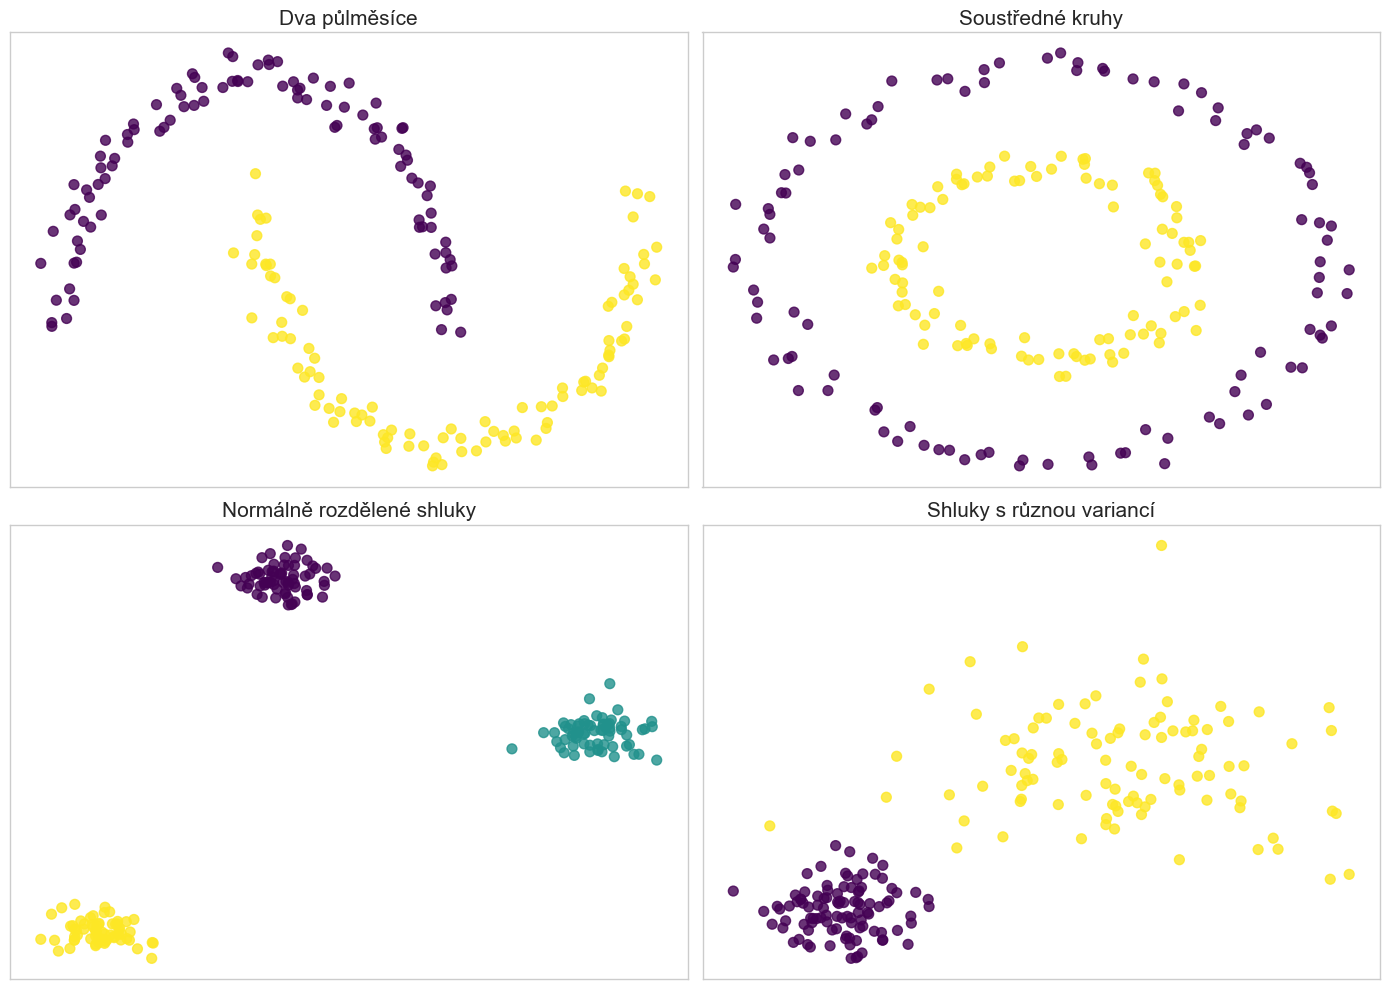

In [2]:
# Funkce pro vytvoření různých datových sad
def create_datasets():
    # Dva půlměsíce
    X_moons, y_moons = make_moons(n_samples=200, noise=0.05, random_state=42)
    
    # Dva soustředné kruhy
    X_circles, y_circles = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)
    
    # Tři normálně rozdělené shluky (vhodné pro K-means)
    X_blobs, y_blobs = make_blobs(n_samples=200, centers=3, cluster_std=0.6, random_state=42)
    
    # Dva shluky s odlišnou variancí
    X_varied = np.vstack([np.random.normal(0, 0.5, (100, 2)),
                        np.random.normal(3, 1.2, (100, 2))])
    y_varied = np.hstack([np.zeros(100), np.ones(100)])
    
    return [(X_moons, y_moons, "Dva půlměsíce"),
            (X_circles, y_circles, "Soustředné kruhy"),
            (X_blobs, y_blobs, "Normálně rozdělené shluky"),
            (X_varied, y_varied, "Shluky s různou variancí")]

# Vytvoření datových sad
datasets = create_datasets()

# Zobrazení datových sad
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, (X, y, title) in enumerate(datasets):
    axes[i].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, alpha=0.8)
    axes[i].set_title(title, fontsize=15)
    axes[i].set_xticks(())
    axes[i].set_yticks(())

plt.tight_layout()
plt.show()

## 2. Implementace Spektrálního shlukování a porovnání s K-means

Nyní porovnáme výsledky K-means a spektrálního shlukování na našich datových sadách.

In [3]:
# def compare_clustering_methods(datasets):
#     fig, axes = plt.subplots(len(datasets), 3, figsize=(18, 5*len(datasets)))
    
#     # Pro každou datovou sadu
#     for i, (X, y_true, title) in enumerate(datasets):
#         # Standardizace dat
#         X_scaled = StandardScaler().fit_transform(X)
#         n_clusters = len(np.unique(y_true))
        
#         # Původní data s pravdivými označeními
#         axes[i, 0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=50, alpha=0.8)
#         axes[i, 0].set_title(f"{title} - Pravdivé shluky", fontsize=12)
#         axes[i, 0].set_xticks(())
#         axes[i, 0].set_yticks(())
        
#         # K-means
#         km = KMeans(n_clusters=n_clusters, random_state=42)
#         y_km = km.fit_predict(X_scaled)
#         silhouette_km = silhouette_score(X_scaled, y_km) if len(np.unique(y_km)) > 1 else 0
        
#         axes[i, 1].scatter(X[:, 0], X[:, 1], c=y_km, cmap='viridis', s=50, alpha=0.8)
#         axes[i, 1].set_title(f"K-means (Silhouette: {silhouette_km:.3f})", fontsize=12)
#         axes[i, 1].set_xticks(())
#         axes[i, 1].set_yticks(())
        
#         # Spektrální shlukování
#         sc = SpectralClustering(
#             n_clusters=n_clusters,
#             affinity='nearest_neighbors',  # Používáme nearest_neighbors pro více flexibility
#             n_neighbors=10,
#             random_state=42
#         )
#         y_sc = sc.fit_predict(X_scaled)
#         silhouette_sc = silhouette_score(X_scaled, y_sc) if len(np.unique(y_sc)) > 1 else 0
        
#         axes[i, 2].scatter(X[:, 0], X[:, 1], c=y_sc, cmap='viridis', s=50, alpha=0.8)
#         axes[i, 2].set_title(f"Spektrální shlukování (Silhouette: {silhouette_sc:.3f})", fontsize=12)
#         axes[i, 2].set_xticks(())
#         axes[i, 2].set_yticks(())
    
#     plt.tight_layout()
#     plt.show()

# # Porovnání metod
# compare_clustering_methods(datasets)

```
UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
```

⚠️ Warning for dataset 'Normálně rozdělené shluky': Spectral graph is not fully connected. Results may be unreliable.


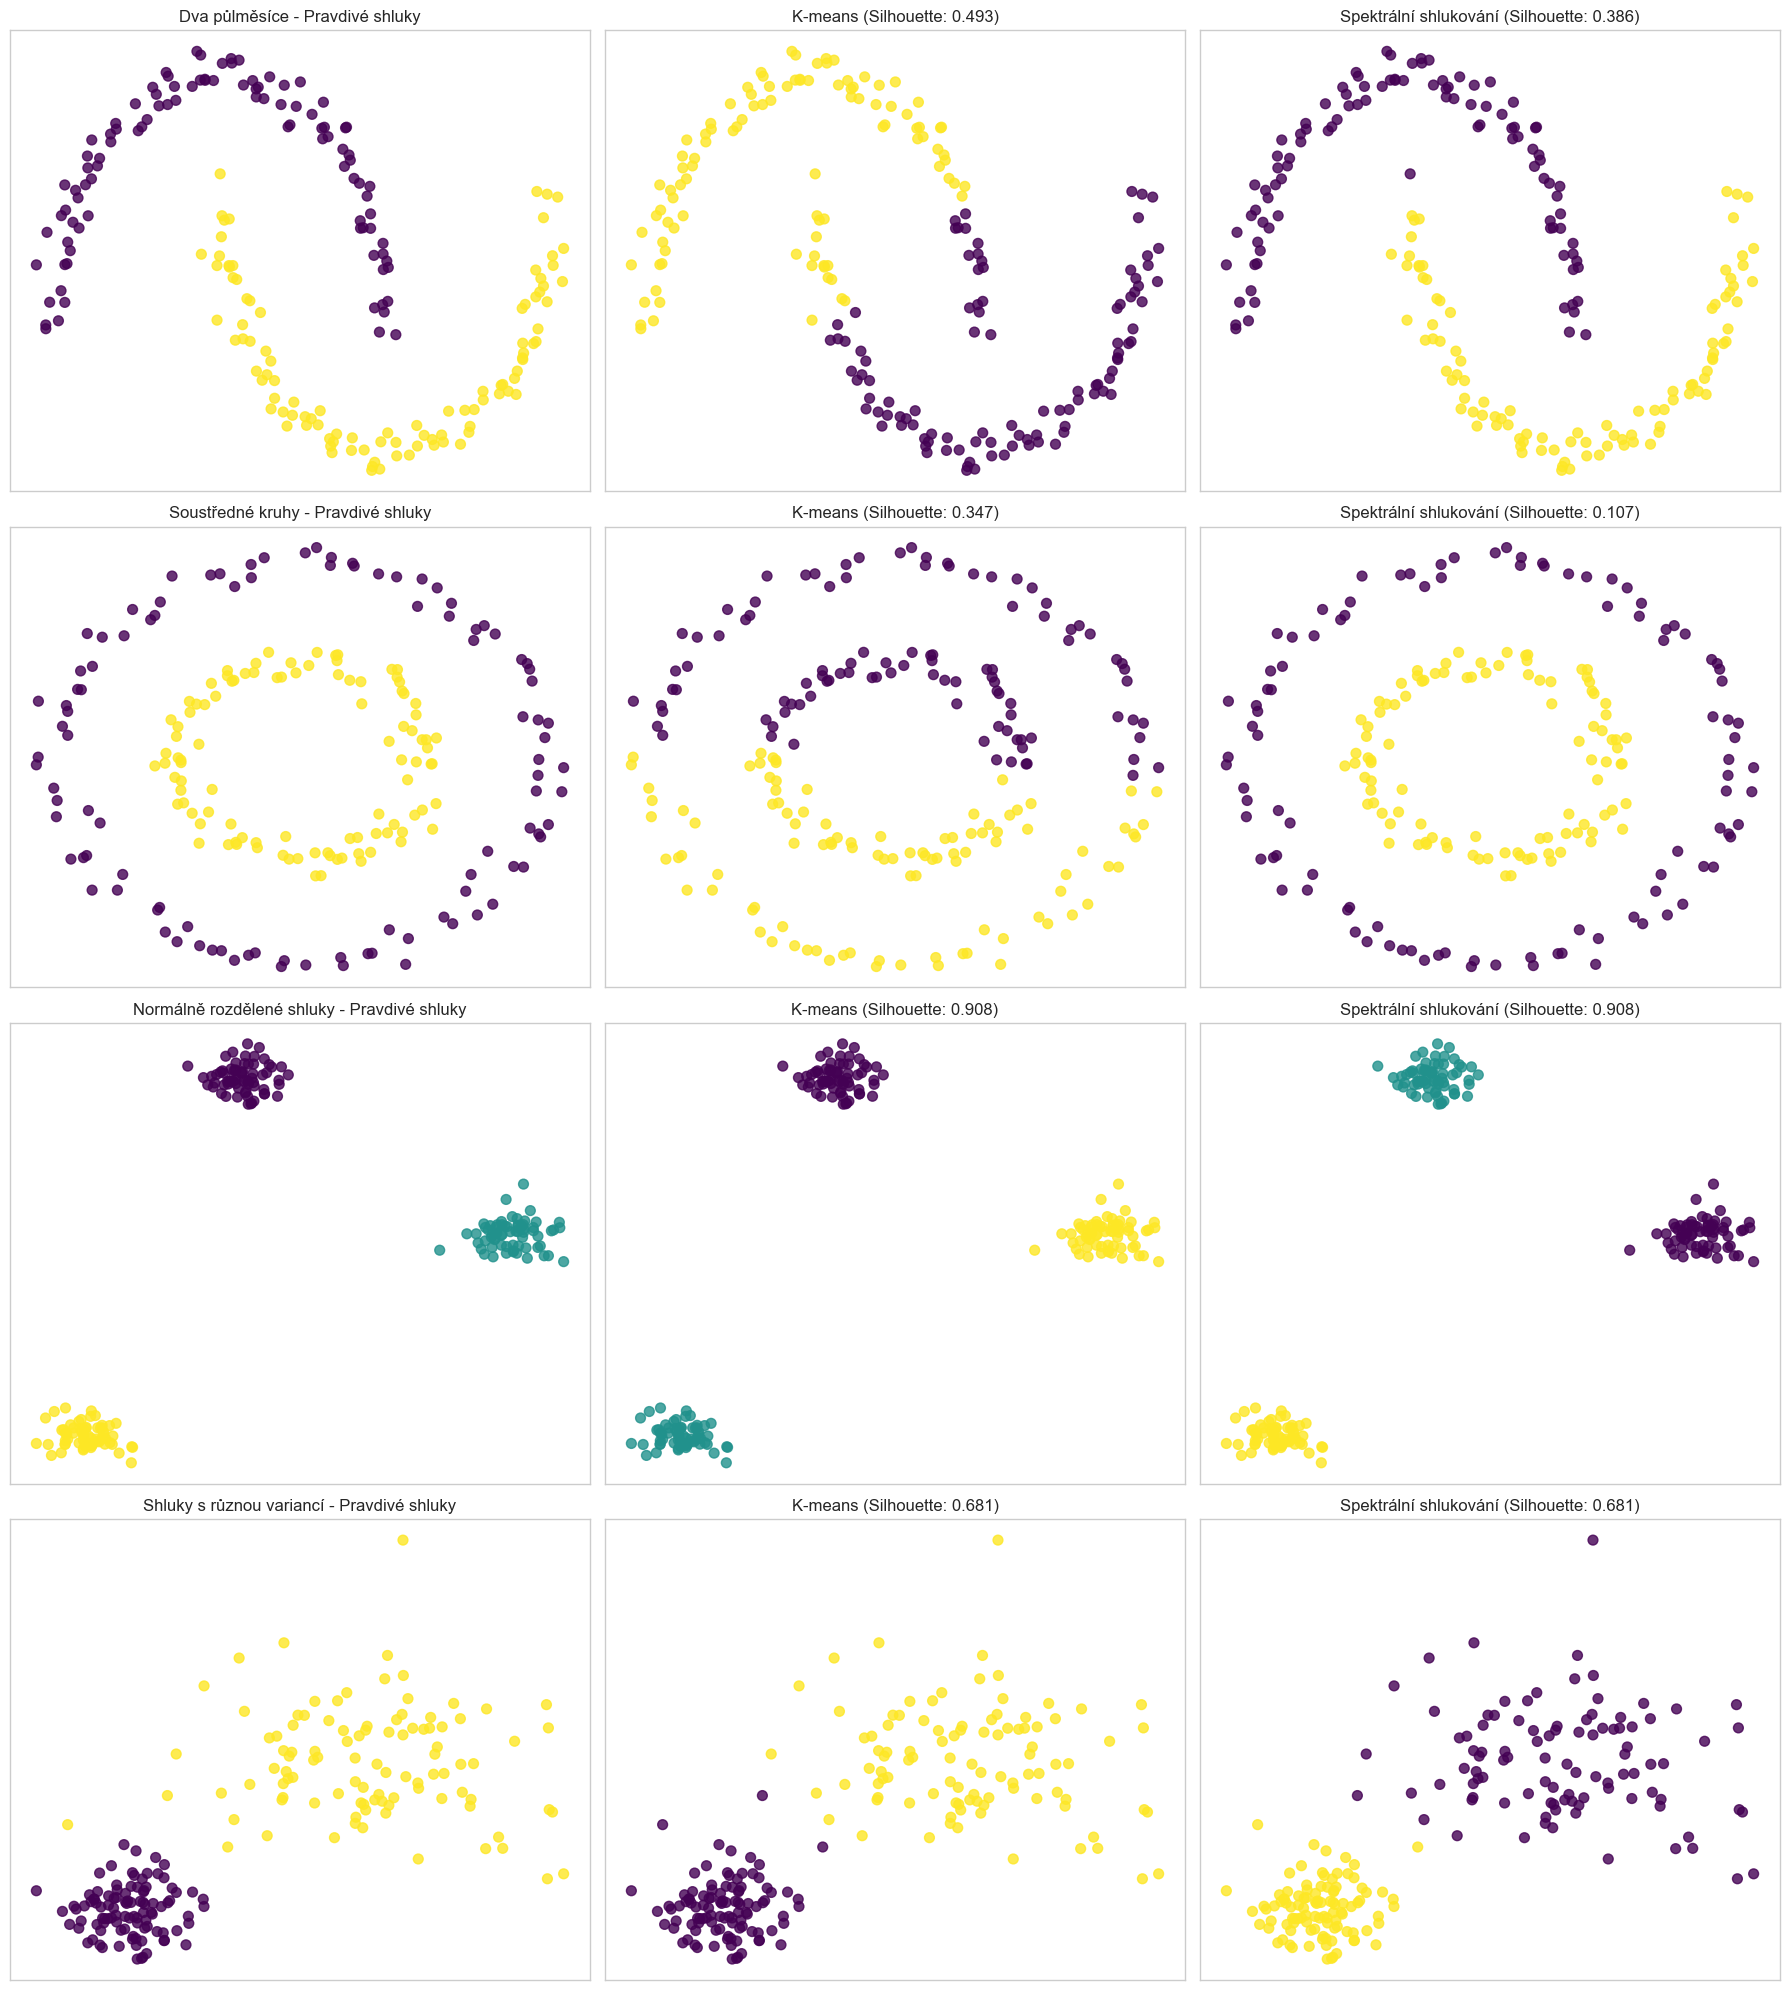

In [4]:
import warnings
from sklearn.neighbors import kneighbors_graph
from sklearn.exceptions import ConvergenceWarning

def compare_clustering_methods(datasets):
    fig, axes = plt.subplots(len(datasets), 3, figsize=(18, 5*len(datasets)))
    
    for i, (X, y_true, title) in enumerate(datasets):
        X_scaled = StandardScaler().fit_transform(X)
        n_clusters = len(np.unique(y_true))
        
        # Ground truth
        axes[i, 0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=50, alpha=0.8)
        axes[i, 0].set_title(f"{title} - Pravdivé shluky", fontsize=12)
        axes[i, 0].set_xticks(())
        axes[i, 0].set_yticks(())

        # KMeans
        km = KMeans(n_clusters=n_clusters, random_state=42)
        y_km = km.fit_predict(X_scaled)
        silhouette_km = silhouette_score(X_scaled, y_km) if len(np.unique(y_km)) > 1 else 0
        axes[i, 1].scatter(X[:, 0], X[:, 1], c=y_km, cmap='viridis', s=50, alpha=0.8)
        axes[i, 1].set_title(f"K-means (Silhouette: {silhouette_km:.3f})", fontsize=12)
        axes[i, 1].set_xticks(())
        axes[i, 1].set_yticks(())

        # Spectral Clustering
        try:
            with warnings.catch_warnings(record=True) as caught_warnings:
                warnings.simplefilter("always", UserWarning)

                sc = SpectralClustering(
                    n_clusters=n_clusters,
                    affinity='nearest_neighbors',
                    n_neighbors=10,
                    random_state=42
                )
                y_sc = sc.fit_predict(X_scaled)

                for w in caught_warnings:
                    if "Graph is not fully connected" in str(w.message):
                        print(f"⚠️ Warning for dataset '{title}': Spectral graph is not fully connected. Results may be unreliable.")

        except Exception as e:
            print(f"❌ Spectral clustering failed for dataset '{title}': {e}")
            y_sc = np.zeros_like(y_true)
            silhouette_sc = 0
        else:
            silhouette_sc = silhouette_score(X_scaled, y_sc) if len(np.unique(y_sc)) > 1 else 0

        axes[i, 2].scatter(X[:, 0], X[:, 1], c=y_sc, cmap='viridis', s=50, alpha=0.8)
        axes[i, 2].set_title(f"Spektrální shlukování (Silhouette: {silhouette_sc:.3f})", fontsize=12)
        axes[i, 2].set_xticks(())
        axes[i, 2].set_yticks(())

    plt.tight_layout()
    plt.show()

# Porovnání metod
compare_clustering_methods(datasets)

## 3. Podrobnější implementace a vysvětlení Spektrálního shlukování

Nyní si ukážeme jednotlivé kroky spektrálního shlukování detailněji.

In [5]:
# # Vybereme datovou sadu s půlměsíci pro názornou ukázku
# X, y_true, _ = datasets[0]  # Půlměsíce

# # 1. Vytvořit graf podobnosti - použijeme graf nejbližších sousedů
# n_neighbors = 10
# affinity_matrix = kneighbors_graph(
#     X, n_neighbors=n_neighbors, include_self=False, mode='distance'
# ).toarray()

# # Převod vzdáleností na podobnosti pomocí Gaussova jádra
# sigma = 1.0
# affinity_matrix = np.exp(-affinity_matrix**2 / (2. * sigma**2))

# # Zajištění symetrie matice podobnosti
# affinity_matrix = 0.5 * (affinity_matrix + affinity_matrix.T)

# # Zobrazení matice podobnosti
# plt.figure(figsize=(10, 8))
# plt.imshow(affinity_matrix, cmap='viridis')
# plt.colorbar(label='Podobnost')
# plt.title('Matice podobnosti (affinity matrix)', fontsize=14)
# plt.show()

# # 2. Výpočet normalizovaného Laplaciánu
# from scipy import sparse
# from scipy.linalg import eigh
# from sklearn.utils.extmath import _deterministic_vector_sign_flip

# # Diagonální matice stupňů
# degree_matrix = np.diag(np.sum(affinity_matrix, axis=1))

# # Laplacián L = D - A
# laplacian = degree_matrix - affinity_matrix

# # Normalizovaný Laplacián L_norm = I - D^(-1/2) * A * D^(-1/2)
# degree_sqrt_inv = np.diag(1.0 / np.sqrt(np.sum(affinity_matrix, axis=1) + 1e-10))
# norm_laplacian = np.eye(affinity_matrix.shape[0]) - degree_sqrt_inv @ affinity_matrix @ degree_sqrt_inv

# # Zobrazení Laplaciánu
# plt.figure(figsize=(14, 6))

# plt.subplot(1, 2, 1)
# plt.imshow(laplacian, cmap='viridis')
# plt.colorbar(label='Hodnota')
# plt.title('Laplacián (L = D - A)', fontsize=12)

# plt.subplot(1, 2, 2)
# plt.imshow(norm_laplacian, cmap='viridis')
# plt.colorbar(label='Hodnota')
# plt.title('Normalizovaný Laplacián', fontsize=12)

# plt.tight_layout()
# plt.show()

# # 3. Spektrální rozklad - výpočet vlastních čísel a vektorů
# n_clusters = 2  # Počet shluků = počet půlměsíců
# eigenvals, eigenvecs = eigh(norm_laplacian, eigvals=(0, n_clusters-1))

# # Seřazení vlastních čísel a vektorů
# idx = eigenvals.argsort()
# eigenvals, eigenvecs = eigenvals[idx], eigenvecs[:, idx]

# # Stabilizace znaménka
# eigenvecs = _deterministic_vector_sign_flip(eigenvecs)

# # Zobrazení vlastních čísel
# plt.figure(figsize=(10, 6))
# plt.bar(np.arange(len(eigenvals)), eigenvals)
# plt.xlabel('Index vlastního čísla', fontsize=12)
# plt.ylabel('Hodnota vlastního čísla', fontsize=12)
# plt.title(f'Prvních {len(eigenvals)} vlastních čísel Laplaciánu', fontsize=14)
# plt.grid(True)
# plt.show()

# # 4. Vizualizace vlastních vektorů
# plt.figure(figsize=(16, 5))
# for i in range(n_clusters):
#     plt.subplot(1, n_clusters, i+1)
#     plt.scatter(X[:, 0], X[:, 1], c=eigenvecs[:, i], cmap='viridis', s=50)
#     plt.colorbar(label=f'Složka {i+1}. vlastního vektoru')
#     plt.title(f'{i+1}. vlastní vektor', fontsize=12)
#     plt.xticks([])
#     plt.yticks([])
# plt.tight_layout()
# plt.show()

# # 5. Projekce do prostoru vlastních vektorů
# X_projected = eigenvecs

# # Vizualizace projekce
# plt.figure(figsize=(10, 8))
# plt.scatter(X_projected[:, 0], X_projected[:, 1], c=y_true, cmap='viridis', s=50)
# plt.colorbar(label='Původní označení')
# plt.title('Projekce dat do prostoru vlastních vektorů', fontsize=14)
# plt.xlabel('1. vlastní vektor', fontsize=12)
# plt.ylabel('2. vlastní vektor', fontsize=12)
# plt.grid(True)
# plt.show()

# # 6. Aplikace K-means na projektovaná data
# kmeans = KMeans(n_clusters=n_clusters, random_state=42)
# labels = kmeans.fit_predict(X_projected)

# # Výsledné shluky zobrazené na původních datech
# plt.figure(figsize=(14, 6))

# plt.subplot(1, 2, 1)
# plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=50)
# plt.title('Originální data', fontsize=14)
# plt.xticks([])
# plt.yticks([])

# plt.subplot(1, 2, 2)
# plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
# plt.title('Spektrální shlukování (ruční implementace)', fontsize=14)
# plt.xticks([])
# plt.yticks([])

# plt.tight_layout()
# plt.show()

```
TypeError: eigh() got an unexpected keyword argument 'eigvals'
```

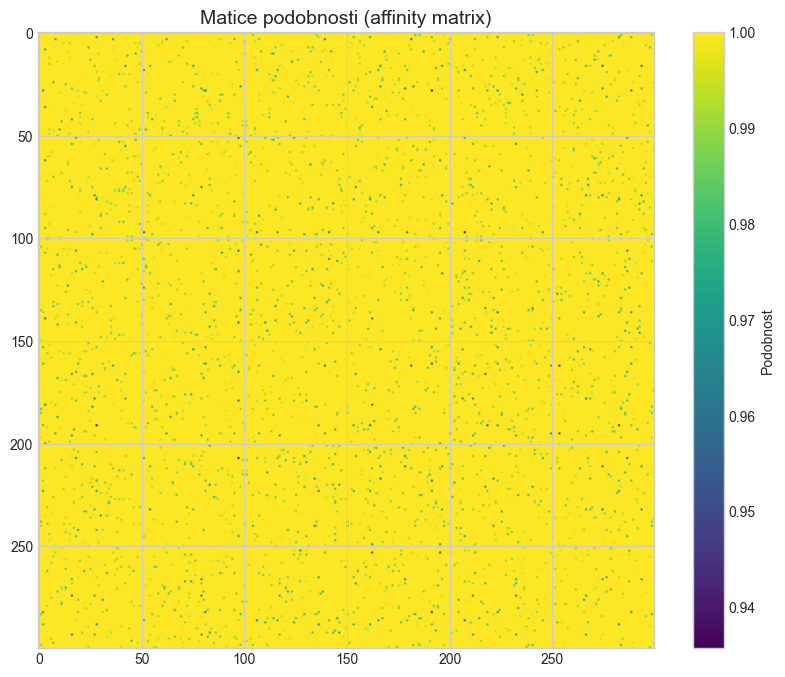

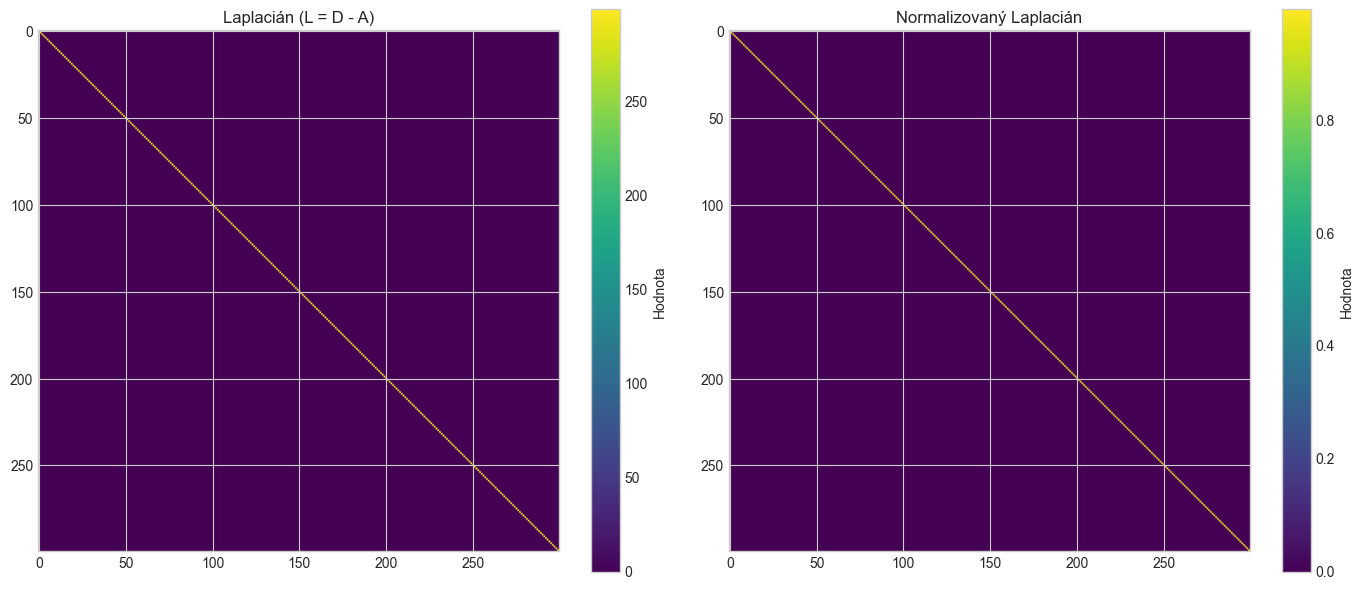

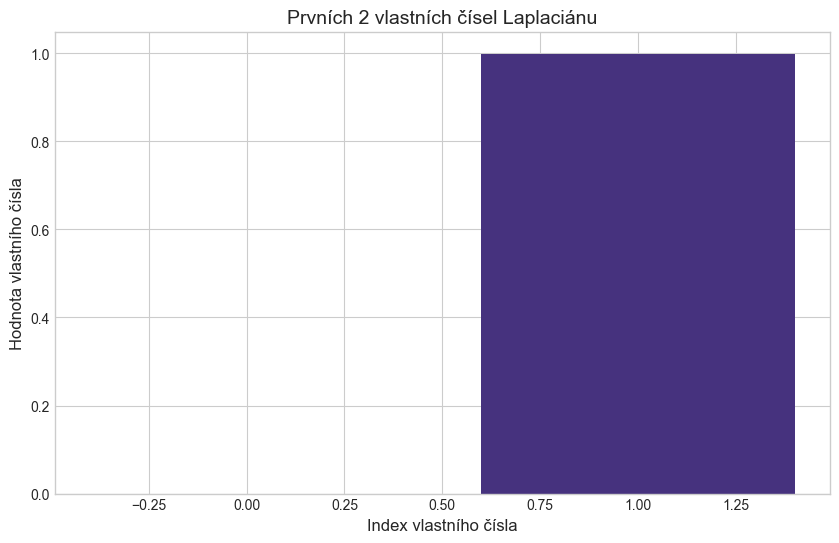

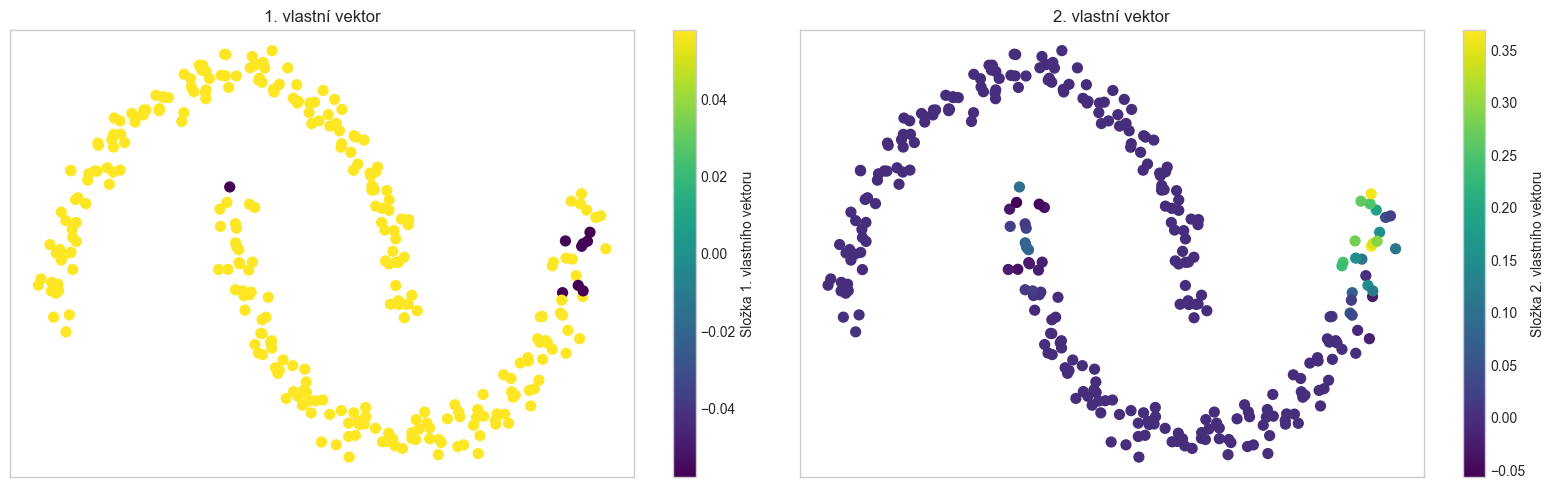

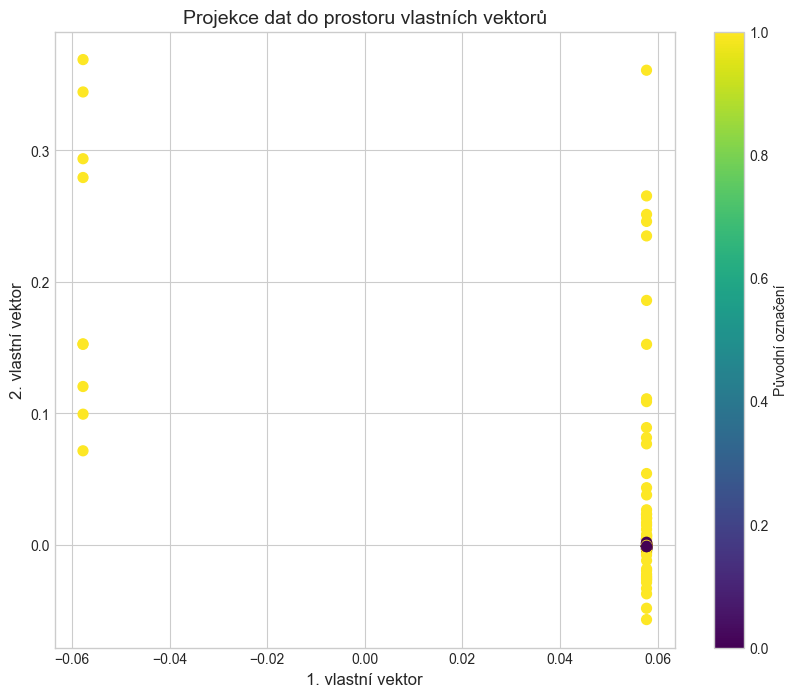

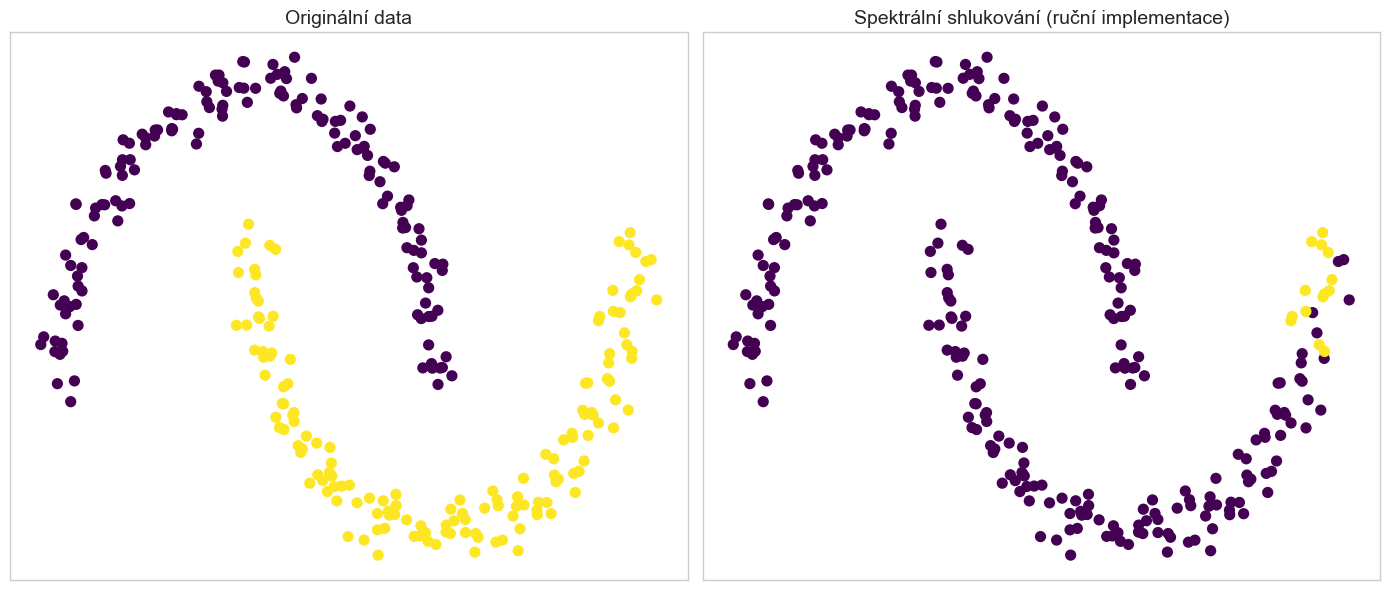

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.linalg import eigh
from sklearn.utils.extmath import _deterministic_vector_sign_flip

# 1. Vybereme datovou sadu s půlměsíci
X, y_true = make_moons(n_samples=300, noise=0.05, random_state=42)

# Standardizace
X = StandardScaler().fit_transform(X)

# 2. Vytvoření grafu podobnosti
n_neighbors = 10
affinity_matrix = kneighbors_graph(
    X, n_neighbors=n_neighbors, include_self=False, mode='distance'
).toarray()

# Gaussovské jádro pro převod vzdáleností na podobnosti
sigma = 1.0
affinity_matrix = np.exp(-affinity_matrix**2 / (2. * sigma**2))

# Zajištění symetrie
affinity_matrix = 0.5 * (affinity_matrix + affinity_matrix.T)

# Zobrazení matice podobnosti
plt.figure(figsize=(10, 8))
plt.imshow(affinity_matrix, cmap='viridis')
plt.colorbar(label='Podobnost')
plt.title('Matice podobnosti (affinity matrix)', fontsize=14)
plt.show()

# 3. Výpočet normalizovaného Laplaciánu
degree_matrix = np.diag(np.sum(affinity_matrix, axis=1))
laplacian = degree_matrix - affinity_matrix
degree_sqrt_inv = np.diag(1.0 / np.sqrt(np.sum(affinity_matrix, axis=1) + 1e-10))
norm_laplacian = np.eye(affinity_matrix.shape[0]) - degree_sqrt_inv @ affinity_matrix @ degree_sqrt_inv

# Zobrazení Laplaciánů
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(laplacian, cmap='viridis')
plt.colorbar(label='Hodnota')
plt.title('Laplacián (L = D - A)', fontsize=12)

plt.subplot(1, 2, 2)
plt.imshow(norm_laplacian, cmap='viridis')
plt.colorbar(label='Hodnota')
plt.title('Normalizovaný Laplacián', fontsize=12)

plt.tight_layout()
plt.show()

# 4. Spektrální rozklad - výpočet vlastních čísel a vektorů
n_clusters = 2
eigenvals, eigenvecs = eigh(norm_laplacian, subset_by_index=(0, n_clusters-1))

# Seřazení vlastních čísel a vektorů
idx = eigenvals.argsort()
eigenvals, eigenvecs = eigenvals[idx], eigenvecs[:, idx]

# Stabilizace znamének
eigenvecs = _deterministic_vector_sign_flip(eigenvecs)

# Zobrazení vlastních čísel
plt.figure(figsize=(10, 6))
plt.bar(np.arange(len(eigenvals)), eigenvals)
plt.xlabel('Index vlastního čísla', fontsize=12)
plt.ylabel('Hodnota vlastního čísla', fontsize=12)
plt.title(f'Prvních {len(eigenvals)} vlastních čísel Laplaciánu', fontsize=14)
plt.grid(True)
plt.show()

# 5. Vizualizace vlastních vektorů
plt.figure(figsize=(16, 5))
for i in range(n_clusters):
    plt.subplot(1, n_clusters, i + 1)
    plt.scatter(X[:, 0], X[:, 1], c=eigenvecs[:, i], cmap='viridis', s=50)
    plt.colorbar(label=f'Složka {i+1}. vlastního vektoru')
    plt.title(f'{i+1}. vlastní vektor', fontsize=12)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

# 6. Projekce do prostoru vlastních vektorů
X_projected = eigenvecs

# Vizualizace projekce
plt.figure(figsize=(10, 8))
plt.scatter(X_projected[:, 0], X_projected[:, 1], c=y_true, cmap='viridis', s=50)
plt.colorbar(label='Původní označení')
plt.title('Projekce dat do prostoru vlastních vektorů', fontsize=14)
plt.xlabel('1. vlastní vektor', fontsize=12)
plt.ylabel('2. vlastní vektor', fontsize=12)
plt.grid(True)
plt.show()

# 7. K-means na projektovaných datech
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X_projected)

# 8. Výsledky
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=50)
plt.title('Originální data', fontsize=14)
plt.xticks([])
plt.yticks([])

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title('Spektrální shlukování (ruční implementace)', fontsize=14)
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

## 4. Zkoumání vlivu parametrů Spektrálního shlukování

Podíváme se na vliv různých typů matic podobnosti (affinity) a dalších parametrů.

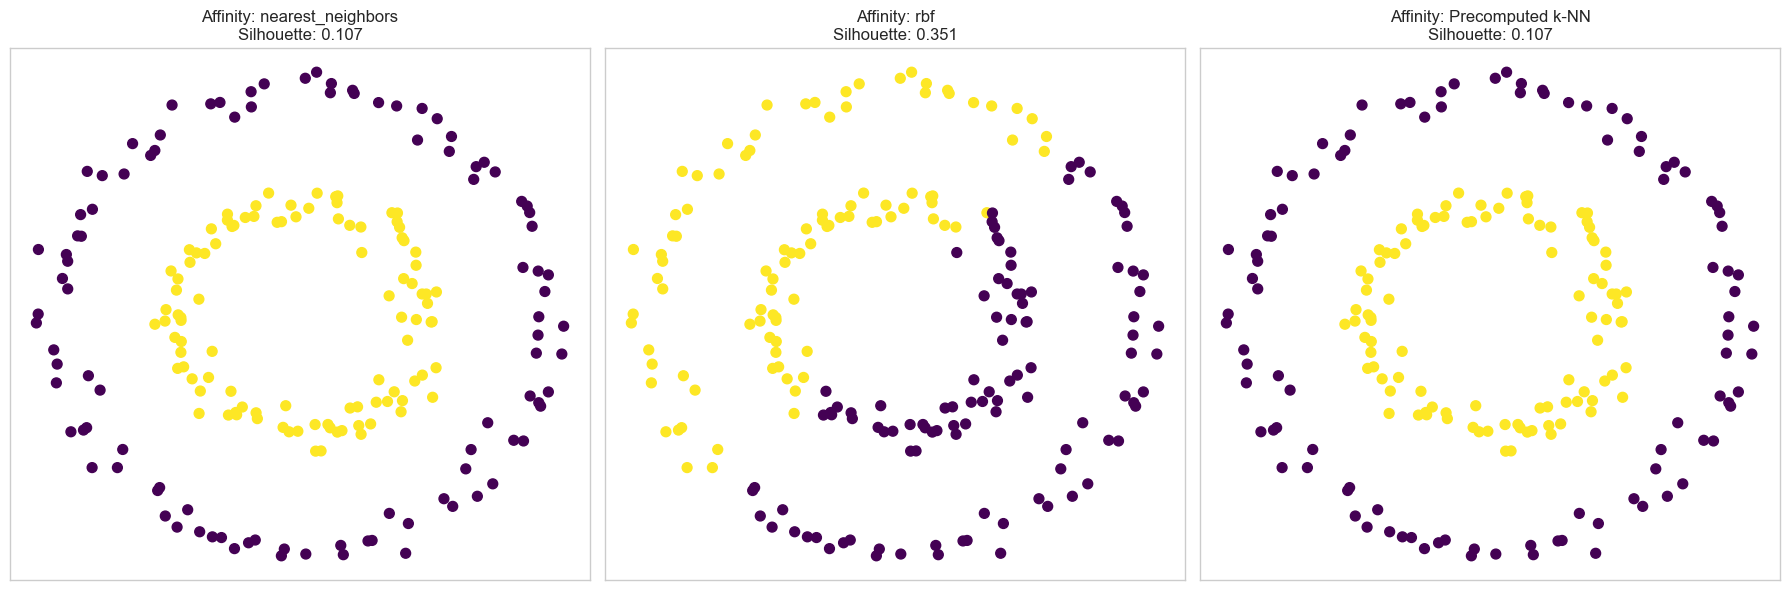

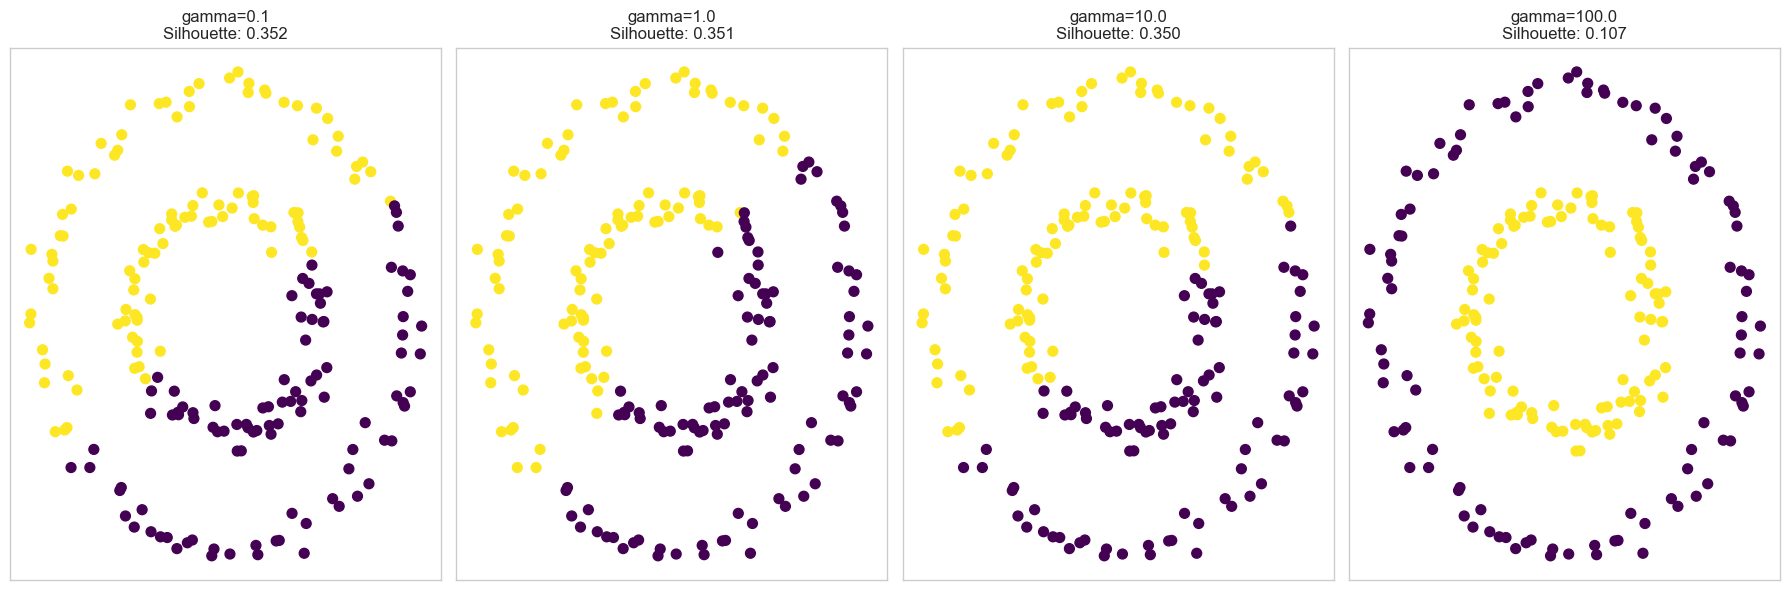

In [7]:
# Vybereme datovou sadu se soustřednými kruhy pro další experimenty
X, y_true, _ = datasets[1]  # Soustředné kruhy

# Různé typy matic podobnosti
affinities = ['nearest_neighbors', 'rbf', 'precomputed_nearest_neighbors']
fig, axes = plt.subplots(1, len(affinities), figsize=(18, 6))

for i, affinity in enumerate(affinities):
    # Pokud je affinity 'precomputed_nearest_neighbors', musíme jej nejprve vypočítat
    if affinity == 'precomputed_nearest_neighbors':
        # Vytvoření grafu nejbližších sousedů
        knn_graph = kneighbors_graph(X, n_neighbors=10, include_self=False, mode='connectivity')
        # Zajištění symetrie
        knn_graph = 0.5 * (knn_graph + knn_graph.T)
        # Použití precomputed matice
        sc = SpectralClustering(n_clusters=2, affinity='precomputed', random_state=42)
        y_pred = sc.fit_predict(knn_graph.toarray())
    else:
        # Standardní použití
        sc = SpectralClustering(n_clusters=2, affinity=affinity, random_state=42)
        y_pred = sc.fit_predict(X)
    
    # Výpočet silhouette score
    silhouette = silhouette_score(X, y_pred) if len(np.unique(y_pred)) > 1 else 0
    
    # Vizualizace
    axes[i].scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=50)
    if affinity == 'precomputed_nearest_neighbors':
        title = 'Precomputed k-NN'
    else:
        title = affinity
    axes[i].set_title(f"Affinity: {title}\nSilhouette: {silhouette:.3f}", fontsize=12)
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.tight_layout()
plt.show()

# Vliv různých hodnot parametru gamma pro RBF kernel
gamma_values = [0.1, 1.0, 10.0, 100.0]
fig, axes = plt.subplots(1, len(gamma_values), figsize=(18, 6))

for i, gamma in enumerate(gamma_values):
    sc = SpectralClustering(n_clusters=2, affinity='rbf', gamma=gamma, random_state=42)
    y_pred = sc.fit_predict(X)
    
    # Výpočet silhouette score
    silhouette = silhouette_score(X, y_pred) if len(np.unique(y_pred)) > 1 else 0
    
    # Vizualizace
    axes[i].scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=50)
    axes[i].set_title(f"gamma={gamma}\nSilhouette: {silhouette:.3f}", fontsize=12)
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.tight_layout()
plt.show()

## 5. Spektrální shlukování na reálných datech

K-Means - Adjusted Rand Index: 0.433
Spectral Clustering - Adjusted Rand Index: 0.600


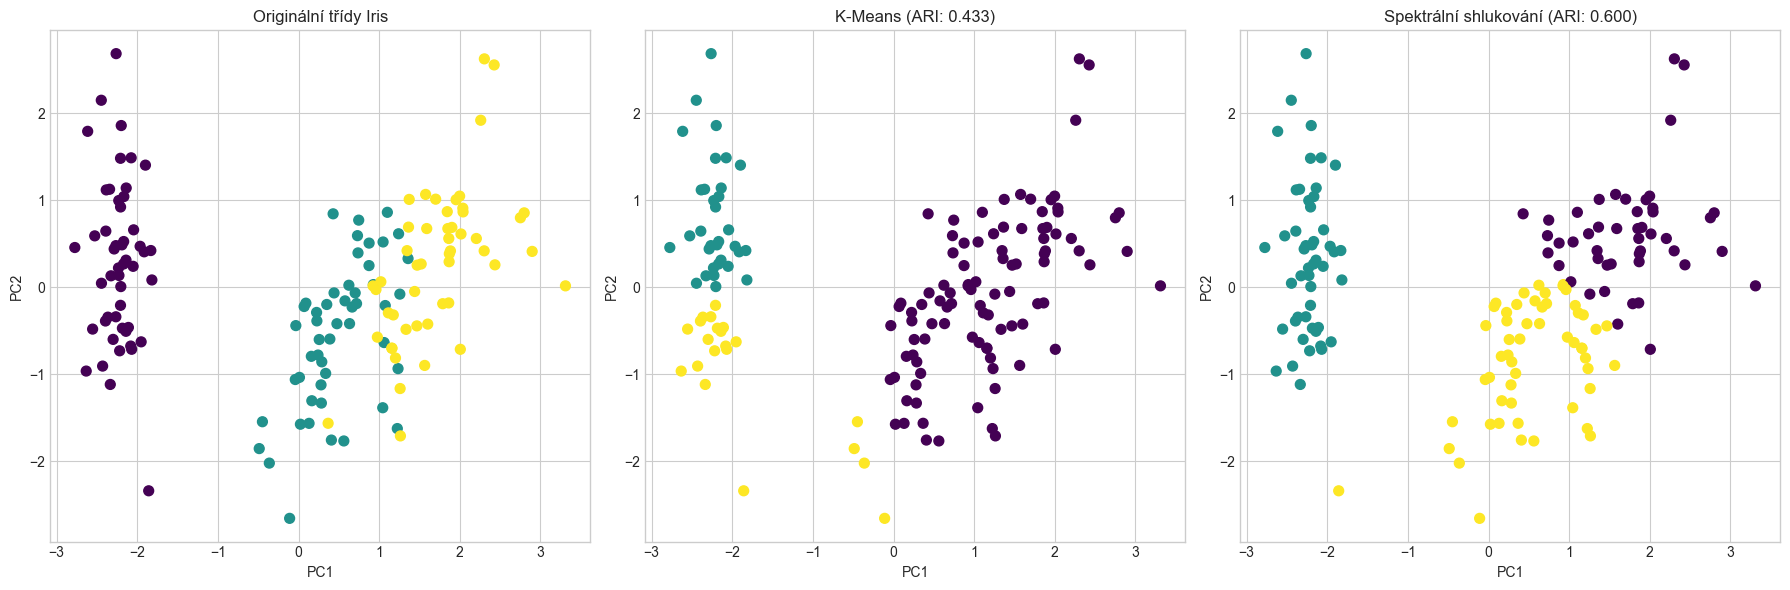

In [8]:
from sklearn.datasets import load_iris
from sklearn.metrics.cluster import adjusted_rand_score

# Načtení Iris datasetu
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Standardizace dat
X_iris_scaled = StandardScaler().fit_transform(X_iris)

# Počet shluků odpovídá počtu tříd v datasetu
n_clusters = len(np.unique(y_iris))

# Aplikace K-means a Spektrálního shlukování
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
y_km = kmeans.fit_predict(X_iris_scaled)

spectral = SpectralClustering(n_clusters=n_clusters, affinity='rbf', gamma=0.5, random_state=42)
y_sp = spectral.fit_predict(X_iris_scaled)

# Vyhodnocení pomocí Adjusted Rand Index
ari_km = adjusted_rand_score(y_iris, y_km)
ari_sp = adjusted_rand_score(y_iris, y_sp)

print(f"K-Means - Adjusted Rand Index: {ari_km:.3f}")
print(f"Spectral Clustering - Adjusted Rand Index: {ari_sp:.3f}")

# Vizualizace výsledků pomocí PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris_scaled)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_iris, cmap='viridis', s=50)
plt.title('Originální třídy Iris', fontsize=12)
plt.xlabel('PC1', fontsize=10)
plt.ylabel('PC2', fontsize=10)

plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_km, cmap='viridis', s=50)
plt.title(f'K-Means (ARI: {ari_km:.3f})', fontsize=12)
plt.xlabel('PC1', fontsize=10)
plt.ylabel('PC2', fontsize=10)

plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sp, cmap='viridis', s=50)
plt.title(f'Spektrální shlukování (ARI: {ari_sp:.3f})', fontsize=12)
plt.xlabel('PC1', fontsize=10)
plt.ylabel('PC2', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Implementace spektrálního shlukování od základů

Pro lepší pochopení algoritmu implementujeme spektrální shlukování bez použití hotové knihovny.

In [9]:
# def spectral_clustering_from_scratch(X, n_clusters, affinity='rbf', gamma=1.0, n_neighbors=10):
#     """
#     Implementace spektrálního shlukování od základů.
    
#     Parametry:
#     X : array-like, tvar (n_samples, n_features)
#         Vstupní data pro shlukování.
#     n_clusters : int
#         Počet požadovaných shluků.
#     affinity : str, default='rbf'
#         Způsob výpočtu matice podobnosti. Možnosti: 'rbf', 'nearest_neighbors'.
#     gamma : float, default=1.0
#         Parametr pro RBF jádro (šířka Gaussovy funkce).
#     n_neighbors : int, default=10
#         Počet sousedů pro metodu nejbližších sousedů.
        
#     Výstup:
#     labels : array, tvar (n_samples,)
#         Označení shluků pro každý bod.
#     """
#     n_samples = X.shape[0]
    
#     # 1. Vytvořit matici podobnosti
#     if affinity == 'rbf':
#         # Vypočítat vzdálenosti mezi všemi páry bodů
#         from sklearn.metrics.pairwise import rbf_kernel
#         affinity_matrix = rbf_kernel(X, gamma=gamma)
    
#     elif affinity == 'nearest_neighbors':
#         # Vytvořit graf k-nejbližších sousedů
#         connectivity = kneighbors_graph(X, n_neighbors=n_neighbors, include_self=False, mode='distance')
#         affinity_matrix = connectivity.toarray()
#         # Převést vzdálenosti na podobnosti
#         affinity_matrix = np.exp(-affinity_matrix**2 / (2. * gamma**2))
#         # Zajistit symetrii
#         affinity_matrix = 0.5 * (affinity_matrix + affinity_matrix.T)
    
#     else:
#         raise ValueError("Podporované hodnoty pro 'affinity' jsou 'rbf' a 'nearest_neighbors'")
    
#     # 2. Vypočítat Laplaceovu matici
#     # Diagonální matice D
#     d = np.sum(affinity_matrix, axis=1)
#     d_inv_sqrt = np.power(d, -0.5, where=d!=0)
#     d_inv_sqrt[~np.isfinite(d_inv_sqrt)] = 0
#     D_inv_sqrt = np.diag(d_inv_sqrt)
    
#     # Normalizovaný Laplacián L_norm = I - D^(-1/2) * W * D^(-1/2)
#     L_norm = np.eye(n_samples) - D_inv_sqrt @ affinity_matrix @ D_inv_sqrt
    
#     # 3. Výpočet vlastních vektorů
#     eigenvals, eigenvecs = eigh(L_norm, eigvals=(0, n_clusters-1))
    
#     # Seřadit vlastní vektory podle vlastních čísel
#     idx = np.argsort(eigenvals)
#     eigenvecs = eigenvecs[:, idx]
    
#     # 4. Normalizace řádků matice vlastních vektorů pro K-means
#     norm_eigenvecs = eigenvecs / np.linalg.norm(eigenvecs, axis=1, keepdims=True)
#     norm_eigenvecs = np.nan_to_num(norm_eigenvecs)
    
#     # 5. Použití K-means na normalizované vlastní vektory
#     kmeans = KMeans(n_clusters=n_clusters, random_state=42)
#     labels = kmeans.fit_predict(norm_eigenvecs)
    
#     return labels

# # Testování naší implementace na datové sadě s půlměsíci
# X, y_true, _ = datasets[0]
# custom_labels = spectral_clustering_from_scratch(X, n_clusters=2, affinity='rbf', gamma=10)

# # Porovnání s implementací ze scikit-learn
# sk_spectral = SpectralClustering(n_clusters=2, affinity='rbf', gamma=10, random_state=42)
# sk_labels = sk_spectral.fit_predict(X)

# # Výpočet podobnosti výsledků pomocí ARI
# ari_custom_vs_true = adjusted_rand_score(y_true, custom_labels)
# ari_sk_vs_true = adjusted_rand_score(y_true, sk_labels)
# ari_custom_vs_sk = adjusted_rand_score(custom_labels, sk_labels)

# print(f"ARI - Vlastní implementace vs. pravdivé označení: {ari_custom_vs_true:.3f}")
# print(f"ARI - Scikit-learn implementace vs. pravdivé označení: {ari_sk_vs_true:.3f}")
# print(f"ARI - Vlastní vs. Scikit-learn implementace: {ari_custom_vs_sk:.3f}")

# # Vizualizace výsledků
# plt.figure(figsize=(18, 6))

# plt.subplot(1, 3, 1)
# plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=50)
# plt.title('Originální třídy', fontsize=12)
# plt.xticks([])
# plt.yticks([])

# plt.subplot(1, 3, 2)
# plt.scatter(X[:, 0], X[:, 1], c=custom_labels, cmap='viridis', s=50)
# plt.title(f'Vlastní implementace (ARI: {ari_custom_vs_true:.3f})', fontsize=12)
# plt.xticks([])
# plt.yticks([])

# plt.subplot(1, 3, 3)
# plt.scatter(X[:, 0], X[:, 1], c=sk_labels, cmap='viridis', s=50)
# plt.title(f'Scikit-learn implementace (ARI: {ari_sk_vs_true:.3f})', fontsize=12)
# plt.xticks([])
# plt.yticks([])

# plt.tight_layout()
# plt.show()

```
TypeError: eigh() got an unexpected keyword argument 'eigvals'
```

ARI - Vlastní implementace vs. pravdivé označení: 0.864
ARI - Scikit-learn implementace vs. pravdivé označení: 0.864
ARI - Vlastní vs. Scikit-learn implementace: 1.000


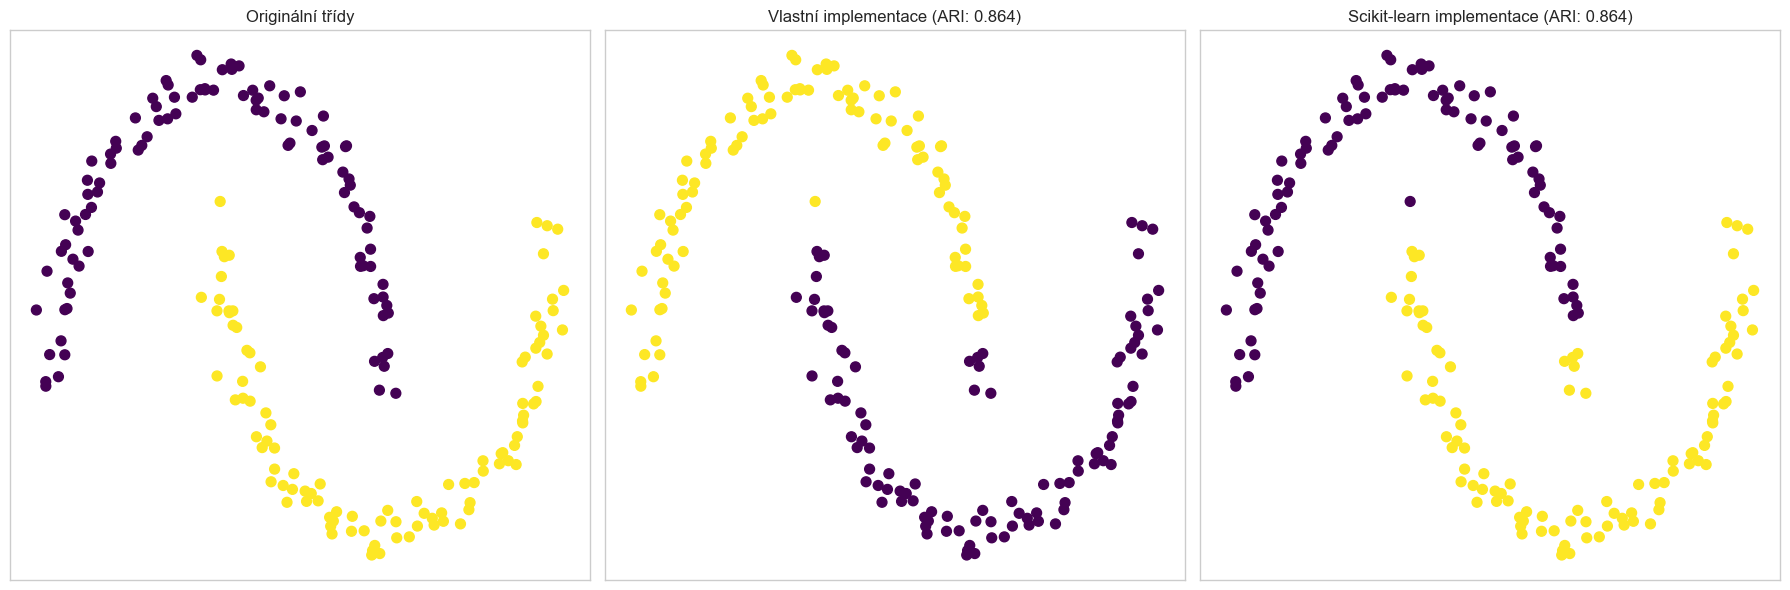

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.neighbors import kneighbors_graph
from scipy.linalg import eigh
from sklearn.datasets import make_moons

def spectral_clustering_from_scratch(X, n_clusters, affinity='rbf', gamma=1.0, n_neighbors=10):
    """
    Implementace spektrálního shlukování od základů.
    
    Parametry:
    X : array-like, tvar (n_samples, n_features)
        Vstupní data pro shlukování.
    n_clusters : int
        Počet požadovaných shluků.
    affinity : str, default='rbf'
        Způsob výpočtu matice podobnosti. Možnosti: 'rbf', 'nearest_neighbors'.
    gamma : float, default=1.0
        Parametr pro RBF jádro (šířka Gaussovy funkce).
    n_neighbors : int, default=10
        Počet sousedů pro metodu nejbližších sousedů.
        
    Výstup:
    labels : array, tvar (n_samples,)
        Označení shluků pro každý bod.
    """
    n_samples = X.shape[0]
    
    # 1. Vytvořit matici podobnosti
    if affinity == 'rbf':
        affinity_matrix = rbf_kernel(X, gamma=gamma)
    
    elif affinity == 'nearest_neighbors':
        connectivity = kneighbors_graph(X, n_neighbors=n_neighbors, include_self=False, mode='distance')
        affinity_matrix = connectivity.toarray()
        affinity_matrix = np.exp(-affinity_matrix**2 / (2. * gamma**2))
        affinity_matrix = 0.5 * (affinity_matrix + affinity_matrix.T)
    
    else:
        raise ValueError("Podporované hodnoty pro 'affinity' jsou 'rbf' a 'nearest_neighbors'")
    
    # 2. Vypočítat Laplaceovu matici
    d = np.sum(affinity_matrix, axis=1)
    d_inv_sqrt = np.power(d, -0.5, where=d!=0)
    d_inv_sqrt[~np.isfinite(d_inv_sqrt)] = 0
    D_inv_sqrt = np.diag(d_inv_sqrt)
    
    # Normalizovaný Laplacián L_norm = I - D^(-1/2) * W * D^(-1/2)
    L_norm = np.eye(n_samples) - D_inv_sqrt @ affinity_matrix @ D_inv_sqrt
    
    # 3. Výpočet vlastních vektorů (oprava pomocí subset_by_index místo eigvals)
    eigenvals, eigenvecs = eigh(L_norm, subset_by_index=[0, n_clusters - 1])
    
    # Seřadit vlastní vektory podle vlastních čísel
    idx = np.argsort(eigenvals)
    eigenvecs = eigenvecs[:, idx]
    
    # 4. Normalizace řádků matice vlastních vektorů pro K-means
    norm_eigenvecs = eigenvecs / np.linalg.norm(eigenvecs, axis=1, keepdims=True)
    norm_eigenvecs = np.nan_to_num(norm_eigenvecs)
    
    # 5. Použití K-means na normalizované vlastní vektory
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(norm_eigenvecs)
    
    return labels

# Testování naší implementace na datové sadě s půlměsíci
X, y_true = make_moons(n_samples=200, noise=0.05, random_state=42)
datasets = [(X, y_true, "Moons")]

custom_labels = spectral_clustering_from_scratch(X, n_clusters=2, affinity='rbf', gamma=10)

# Porovnání s implementací ze scikit-learn
sk_spectral = SpectralClustering(n_clusters=2, affinity='rbf', gamma=10, random_state=42)
sk_labels = sk_spectral.fit_predict(X)

# Výpočet podobnosti výsledků pomocí ARI
ari_custom_vs_true = adjusted_rand_score(y_true, custom_labels)
ari_sk_vs_true = adjusted_rand_score(y_true, sk_labels)
ari_custom_vs_sk = adjusted_rand_score(custom_labels, sk_labels)

print(f"ARI - Vlastní implementace vs. pravdivé označení: {ari_custom_vs_true:.3f}")
print(f"ARI - Scikit-learn implementace vs. pravdivé označení: {ari_sk_vs_true:.3f}")
print(f"ARI - Vlastní vs. Scikit-learn implementace: {ari_custom_vs_sk:.3f}")

# Vizualizace výsledků
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=50)
plt.title('Originální třídy', fontsize=12)
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 2)
plt.scatter(X[:, 0], X[:, 1], c=custom_labels, cmap='viridis', s=50)
plt.title(f'Vlastní implementace (ARI: {ari_custom_vs_true:.3f})', fontsize=12)
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 3)
plt.scatter(X[:, 0], X[:, 1], c=sk_labels, cmap='viridis', s=50)
plt.title(f'Scikit-learn implementace (ARI: {ari_sk_vs_true:.3f})', fontsize=12)
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

## 7. Shrnutí spektrálního shlukování

### Výhody spektrálního shlukování:
- Schopnost identifikovat shluky s komplexními tvary
- Založeno na solidních matematických základech
- Flexibilita díky různým typům matic podobnosti
- Často lepší výsledky než K-means na nelineárních datech

### Nevýhody spektrálního shlukování:
- Výpočetně náročnější než K-means, zejména pro velké datové sady
- Vyžaduje specifikaci počtu shluků, podobně jako K-means
- Citlivé na volbu parametrů (gamma, typ afinity, atd.)
- Výpočet matice podobnosti může být paměťově náročný pro velké datové sady

### Kdy použít spektrální shlukování:
- Když data obsahují shluky komplexních tvarů (např. kruhy, spirály)
- Když K-means dává špatné výsledky kvůli nelineární struktuře dat
- Když máte menší až střední velikost datové sady
- Když je důležité zachytit globální strukturu dat

### Kdy nepoužívat spektrální shlukování:
- Na velmi velké datové sady (paměťové a časové nároky)
- Když jsou shluky dobře oddělené a kulovité (K-means může být efektivnější)
- Když je obtížné odhadnout vhodné parametry pro konstrukci grafu podobnosti

### Typické aplikace spektrálního shlukování:
- Segmentace obrazu
- Detekce komunit v sociálních sítích
- Analýza molekulárních dat
- Segmentace zákazníků s komplexní strukturou preferencí
- Analýza textových dat